# Embedding Space Analysis (v2)

Analyzes intent embeddings from `nl_command_pairs_flat_train_v2` and visualizes structure in 2D.

In [1]:
import json
import random
from pathlib import Path
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from models.intent_embedder import ToolIntentEmbedder
from models.projection_head import ProjectionHead


/scratch4/home/akrik/base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_PATH = ROOT / 'data/man/nl_command_pairs_flat_train_v2.jsonl'
PHASE1_CKPT = ROOT / 'checkpoints/intent_embedder/best_model.pt'
MAX_SAMPLES = 4000
SEED = 42
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'

print('device:', DEVICE)
print('data:', DATA_PATH)
print('phase1:', PHASE1_CKPT)

device: cuda:0
data: /scratch4/home/akrik/NTILC/data/man/nl_command_pairs_flat_train_v2.jsonl
phase1: /scratch4/home/akrik/NTILC/checkpoints/intent_embedder/best_model.pt


In [3]:
def load_jsonl(path):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

rows = load_jsonl(DATA_PATH)
random.seed(SEED)
random.shuffle(rows)
rows = rows[:MAX_SAMPLES]

tool_counts = {}
for r in rows:
    t = r['tool']
    tool_counts[t] = tool_counts.get(t, 0) + 1

print('samples:', len(rows))
print('unique tools:', len(tool_counts))
print('top tools:', sorted(tool_counts.items(), key=lambda x: -x[1])[:10])

samples: 4000
unique tools: 941
top tools: [('pmdalinux', 15), ('vgdb', 12), ('ipcs', 12), ('pmlogmv', 11), ('stg-completion', 11), ('nfs4_setfacl, nfs4_editfacl', 11), ('updatedb', 11), ('PCPIntro', 11), ('falcodump', 10), ('dpauxmon', 10)]


In [4]:
ckpt = torch.load(PHASE1_CKPT, map_location=DEVICE, weights_only=False)
cfg = ckpt.get('config', {})
dtype_map = {'float16': torch.float16, 'bfloat16': torch.bfloat16, 'float32': torch.float32}
model_torch_dtype = cfg.get('torch_dtype', 'bfloat16')
use_dtype = dtype_map.get(model_torch_dtype, torch.float32)

intent_embedder = ToolIntentEmbedder(
    model_name=cfg.get('encoder_model', 'Qwen/Qwen3.5-9B'),
    embedding_dim=cfg.get('intent_embedding_dim', 1024),
    pooling_strategy=cfg.get('pooling_strategy', 'attention'),
    dropout=cfg.get('dropout', 0.15),
    torch_dtype=model_torch_dtype,
    max_length=cfg.get('max_length', 512),
).to(DEVICE)
intent_embedder.load_state_dict(ckpt['intent_embedder_state_dict'])
intent_embedder.eval()

projection_head = ProjectionHead(
    input_dim=cfg.get('intent_embedding_dim', 1024),
    output_dim=cfg.get('projection_dim', 128),
    dropout=cfg.get('dropout', 0.15),
).to(DEVICE).to(use_dtype)
projection_head.load_state_dict(ckpt['projection_head_state_dict'])
projection_head.eval()

print('Loaded Phase 1 checkpoint.')

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 759/759 [00:00<00:00, 1706.64it/s, Materializing param=visual.pos_embed.weight]                                 
Qwen3_5Model LOAD REPORT from: Qwen/Qwen3.5-9B
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded Phase 1 checkpoint.


In [5]:
def batched(xs, n=64):
    for i in range(0, len(xs), n):
        yield xs[i:i+n]

tool_calls = [{'tool': r['tool'], 'arguments': {'command': r['command']}} for r in rows]
queries = [r['nl_query'] for r in rows]
tool_names = sorted(set(r['tool'] for r in rows))
tool_to_idx = {t:i for i,t in enumerate(tool_names)}
labels = np.array([tool_to_idx[r['tool']] for r in rows])

all_proj = []
with torch.no_grad():
    for tc_batch, q_batch in zip(batched(tool_calls, 64), batched(queries, 64)):
        emb = intent_embedder(tool_calls=tc_batch, queries=q_batch)
        proj = projection_head(emb)
        all_proj.append(proj.float().cpu())

proj = torch.cat(all_proj, dim=0).numpy()
print('Projected shape:', proj.shape)

Projected shape: (4000, 128)


In [6]:
if len(set(labels.tolist())) > 1:
    sil = silhouette_score(proj, labels, metric='cosine')
    print('Silhouette (cosine):', round(float(sil), 4))
else:
    print('Not enough label variety for silhouette.')

Silhouette (cosine): 0.6703


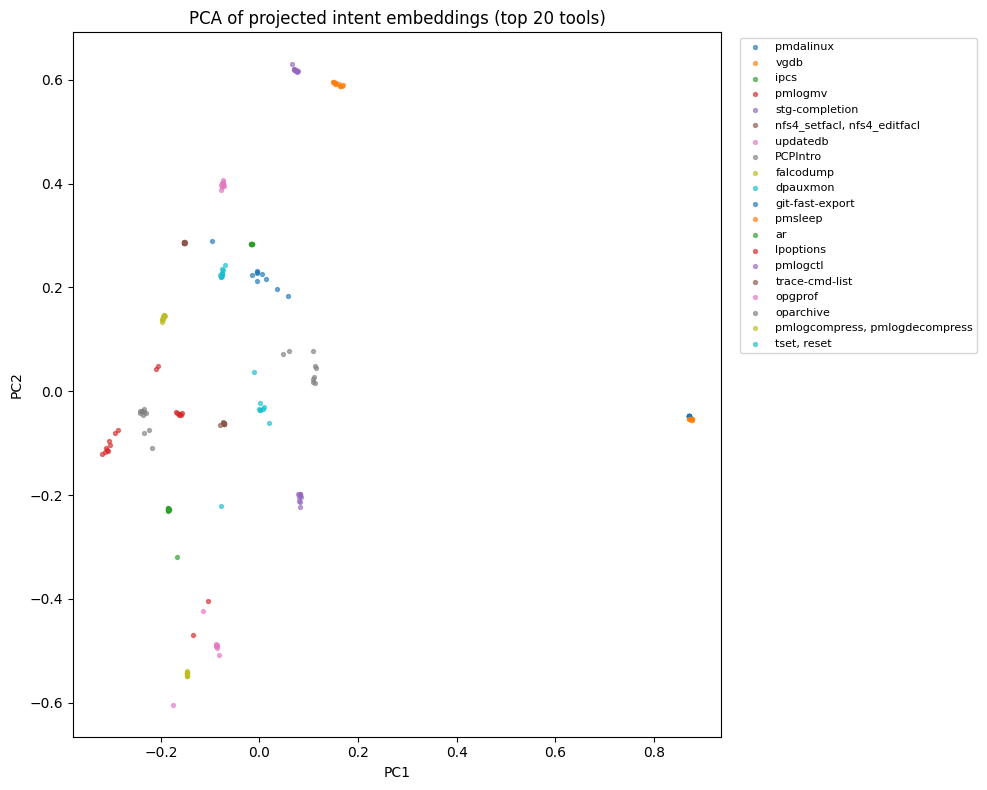

In [7]:
pca = PCA(n_components=2, random_state=SEED)
xy = pca.fit_transform(proj)

# Plot only top-k most frequent tools for readability
top_tools = [t for t,_ in sorted(tool_counts.items(), key=lambda x: -x[1])[:20]]
mask = np.array([rows[i]['tool'] in top_tools for i in range(len(rows))])

plt.figure(figsize=(10, 8))
for t in top_tools:
    idx = [i for i in range(len(rows)) if rows[i]['tool'] == t]
    plt.scatter(xy[idx,0], xy[idx,1], s=8, alpha=0.6, label=t)
plt.title('PCA of projected intent embeddings (top 20 tools)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Nearest neighbors sanity check (same-tool neighborhood quality)
from sklearn.metrics.pairwise import cosine_similarity
S = cosine_similarity(proj, proj)
np.fill_diagonal(S, -1.0)

sample_ids = random.sample(range(len(rows)), min(10, len(rows)))
for i in sample_ids:
    nn = int(np.argmax(S[i]))
    print('---')
    print('Query:   ', rows[i]['nl_query'])
    print('Tool:    ', rows[i]['tool'])
    print('NN tool: ', rows[nn]['tool'])
    print('NN query:', rows[nn]['nl_query'])

---
Query:    Filter data with event_filter.so and pass the argument 'filter_by=cpu0'.
Tool:     perf-dlfilter
NN tool:  perf-dlfilter
NN query: Use the filter in stats_filter.so and pass the argument 'show_total=true'.
---
Query:    Obtain repository info using the -z flag for null-separated values.
Tool:     git-repo
NN tool:  git-repo
NN query: Show information about the repository in key-value format.
---
Query:    Log in to the 'data' group with a fresh login environment.
Tool:     newgrp
NN tool:  newgrp
NN query: Log in to a new group with a fresh login environment.
---
Query:    Generate a SHA512 checksum for 'backup.tar' using binary mode.
Tool:     sha512sum
NN tool:  sha512sum
NN query: Check the integrity of a file using the checksum provided in 'checksums.txt'.
---
Query:    Export a build directory with a detailed commit message body.
Tool:     flatpak-build-export
NN tool:  flatpak-build-export
NN query: Export a build and include a specific file even though it matches a

: 